In [26]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import read_json

from mastercard import dist_visualisation, dist_categorical_visualisation



In [27]:
PROCESSED_DATA = Path("../data/processed")

In [28]:
# RAW_DATA

In [29]:
df = pd.read_parquet(PROCESSED_DATA / 'transactions.parquet')

In [30]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0


In [31]:
print('Initial shape', df.shape)

Initial shape (500000, 14)


In [32]:
# List features
df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'merchant_id', 'amount',
       'channel', 'currency', 'device', 'location', 'payment_method',
       'is_international', 'session_length_seconds', 'is_first_time_merchant',
       'is_fraud'],
      dtype='object')

In [33]:
df.dtypes

transaction_id                    object
timestamp                 datetime64[ns]
user_id                           object
merchant_id                       object
amount                           float64
channel                           object
currency                          object
device                            object
location                          object
payment_method                    object
is_international                   int64
session_length_seconds             int64
is_first_time_merchant             int64
is_fraud                           int64
dtype: object

In [34]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0


In [35]:
df.sample(n=10)

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
389935,TX389935,2022-09-28 02:21:00,U11213,M1000,23.00,online,EUR,Web,"{'lat': 48.66043, 'long': 22.364916}",mobile_payment,1,235,0,0
115181,TX115181,2022-07-17 15:14:00,U08954,M0106,16.55,mobile,EUR,Android,"{'lat': 50.685176, 'long': 31.80713}",credit_card,1,758,1,0
422347,TX422347,2023-06-22 00:02:00,U02477,M0440,2.32,mobile,EUR,Web,"{'lat': 48.639705, 'long': 26.502901}",mobile_payment,1,643,1,1
316071,TX316071,2023-01-22 10:48:00,U05853,M0009,200.70,mobile,EUR,Android,"{'lat': 63.519204, 'long': 17.507103}",bank_transfer,1,797,0,0
333919,TX333919,2023-03-14 04:15:00,U11424,M0650,5.05,in-store,EUR,Android,"{'lat': 49.887472, 'long': 31.624131}",mobile_payment,0,715,0,0
259207,TX259207,2022-08-23 07:21:00,U06869,M0183,71.85,mobile,EUR,Android,"{'lat': 51.029945, 'long': 24.742936}",debit_card,1,470,1,0
100092,TX100092,2023-09-30 13:00:00,U19535,M0255,86.24,online,EUR,Web,"{'lat': 57.071266, 'long': 5.772167}",bank_transfer,1,503,1,0
402053,TX402053,2023-11-10 06:14:00,U01391,M0588,11.86,in-store,EUR,iOS,"{'lat': 35.337837, 'long': 27.500679}",bank_transfer,1,344,1,0
135956,TX135956,2022-07-21 14:32:00,U13352,M0066,71.69,mobile,EUR,Web,"{'lat': 65.521851, 'long': 34.409417}",bank_transfer,1,270,1,0
186254,TX186254,2023-01-18 17:49:00,U17335,M0441,55.22,online,EUR,iOS,"{'lat': 57.572212, 'long': 22.133302}",mobile_payment,1,211,1,0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   transaction_id          500000 non-null  object        
 1   timestamp               500000 non-null  datetime64[ns]
 2   user_id                 500000 non-null  object        
 3   merchant_id             500000 non-null  object        
 4   amount                  500000 non-null  float64       
 5   channel                 500000 non-null  object        
 6   currency                500000 non-null  object        
 7   device                  500000 non-null  object        
 8   location                500000 non-null  object        
 9   payment_method          500000 non-null  object        
 10  is_international        500000 non-null  int64         
 11  session_length_seconds  500000 non-null  int64         
 12  is_first_time_merchant  500000

## Descriptive statistics

- univariate analysis
- bivariate analysis
- multivariate analysis

In [37]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,500000,2022-12-31 16:45:04.497720576,2022-01-01 00:06:00,2022-07-01 11:03:45,2022-12-31 20:08:30,2023-07-02 08:45:15,2023-12-31 23:57:00,NaN
amount,500000.0,49.915662,0.0,14.37,34.56,69.1725,714.86,49.990657
is_international,500000.0,0.928662,0.0,1.0,1.0,1.0,1.0,0.257389
session_length_seconds,500000.0,614.987182,30.0,323.0,614.0,907.0,1200.0,338.091496
is_first_time_merchant,500000.0,0.501248,0.0,0.0,1.0,1.0,1.0,0.499999
is_fraud,500000.0,0.084822,0.0,0.0,0.0,0.0,1.0,0.278617


### Target variable

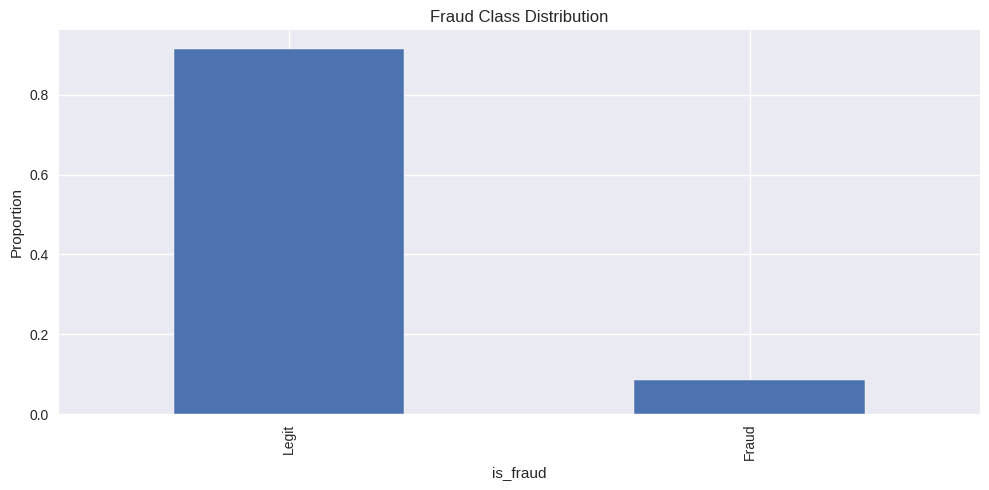

In [38]:
fraud_counts = df['is_fraud'].value_counts(normalize=True)

fix, ax = plt.subplots(figsize=(10, 5))

fraud_counts.plot(kind='bar', ax=ax)
ax.set_title('Fraud Class Distribution')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legit', 'Fraud'])
ax.set_ylabel('Proportion')

plt.tight_layout()
plt.show()

##### Summary: Class distribution is highly imbalanced

- accuracy - will be misleading
- use metrics like F1-score, Recall, ROC-AUC
- consider resampling (undersample, oversample)
- use algorithms with bulit-in the support imbalanced data (e.g. XGBoost)

### Numerical features

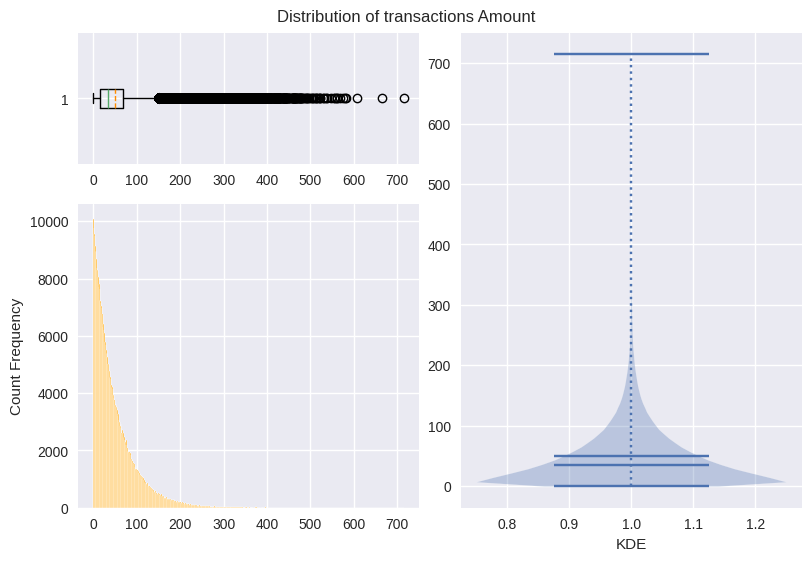

In [39]:
dist_visualisation(df['amount'], title='Distribution of transactions Amount')

In [40]:
df.loc[df['amount'] < 1, 'amount'].count()

np.int64(9986)

In [41]:
df.loc[df['amount'] == 0, 'amount'].count()

np.int64(43)

In [42]:
df['amount'].describe()

count    500000.000000
mean         49.915662
std          49.990657
min           0.000000
25%          14.370000
50%          34.560000
75%          69.172500
max         714.860000
Name: amount, dtype: float64

#### Summary: amount is strongly right-skewed with a long tail, this suggest the presence of outliers

- recommendation: apply log transformation (e.g.log1p) for algorithms sensitive to distribution shape

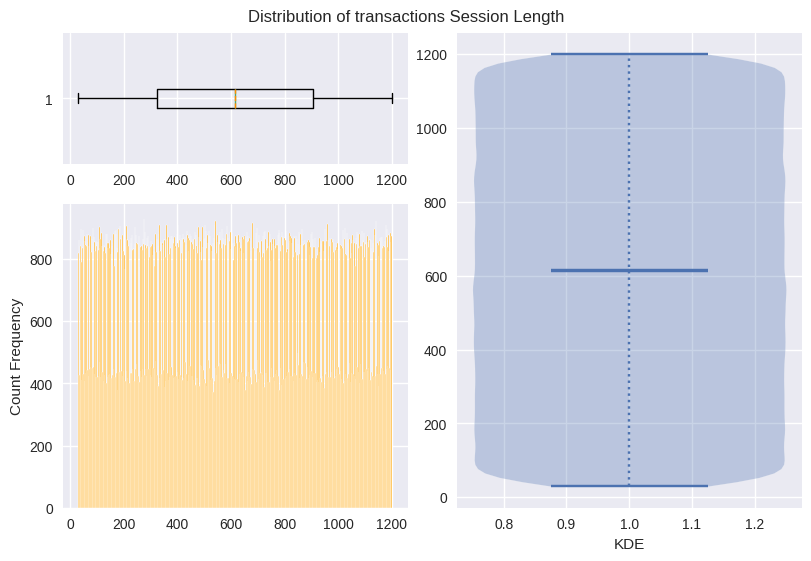

In [43]:
dist_visualisation(df['session_length_seconds'], title='Distribution of transactions Session Length')

#### Summary: session_length_seconds is uniform distributed, which is unusual in real behavioral data

- indicates synthetic generation or flattening
- low predictive power unless frauds are focused in specific ranges (to be checked later)

## Categorical features

In [44]:
df.dtypes

transaction_id                    object
timestamp                 datetime64[ns]
user_id                           object
merchant_id                       object
amount                           float64
channel                           object
currency                          object
device                            object
location                          object
payment_method                    object
is_international                   int64
session_length_seconds             int64
is_first_time_merchant             int64
is_fraud                           int64
dtype: object

In [45]:
df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'merchant_id', 'amount',
       'channel', 'currency', 'device', 'location', 'payment_method',
       'is_international', 'session_length_seconds', 'is_first_time_merchant',
       'is_fraud'],
      dtype='object')

In [46]:
categorical_cols = ['channel', 'currency', 'device', 'payment_method', 'is_international', 'is_first_time_merchant' ]

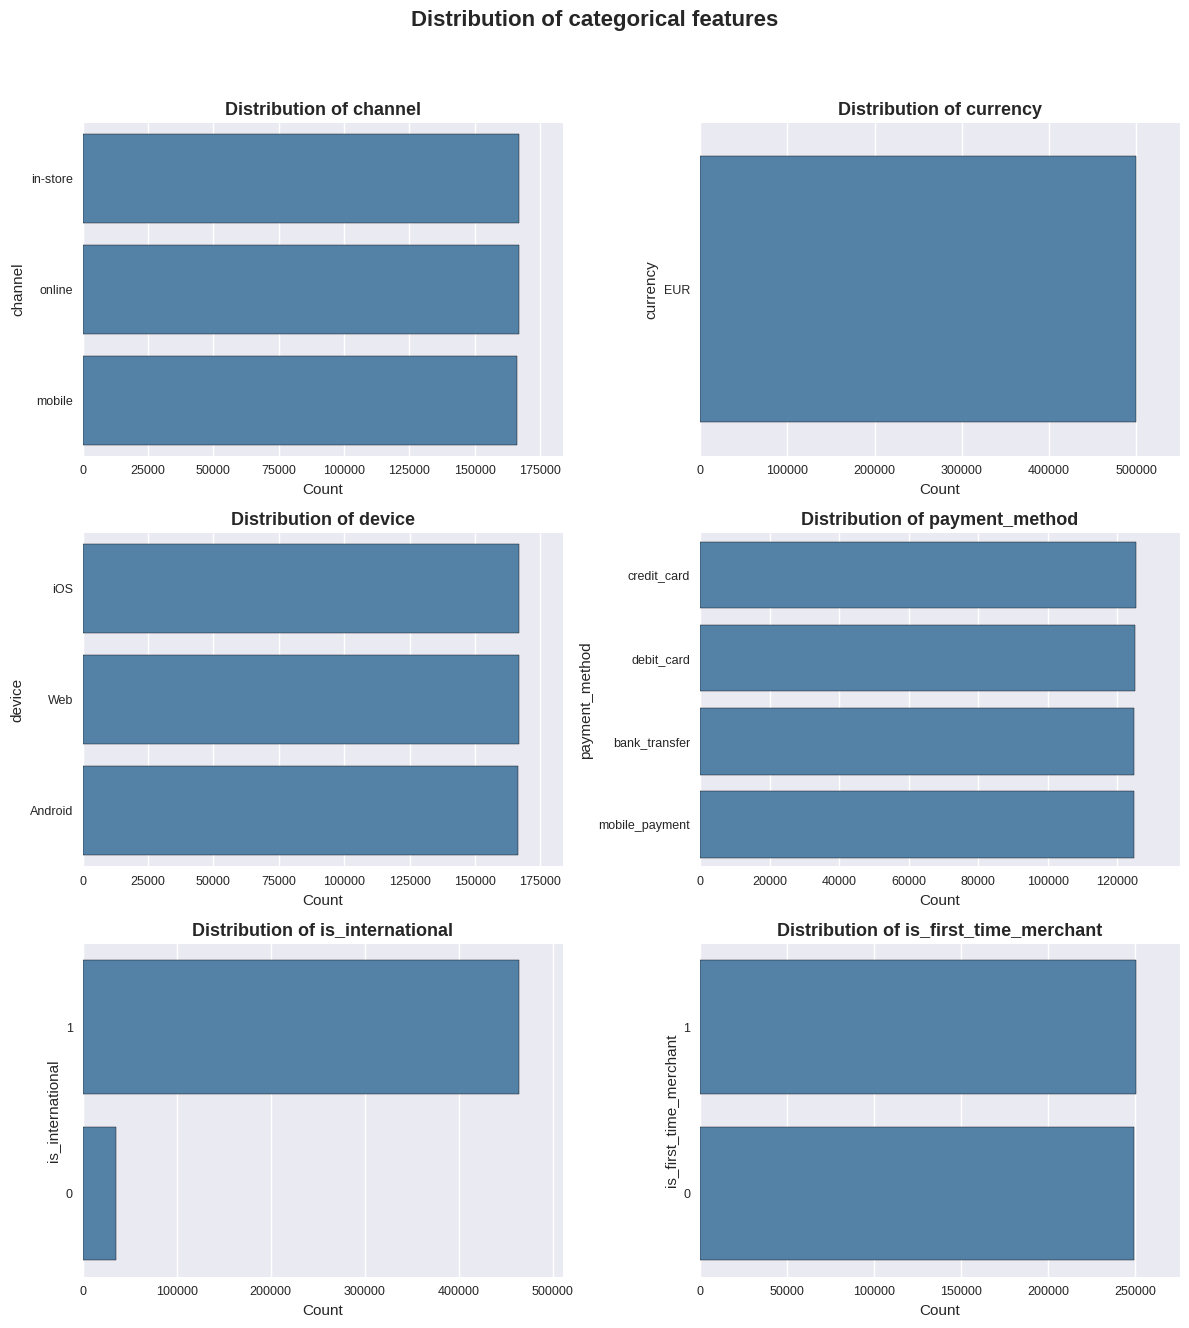

In [47]:
fig, ax = dist_categorical_visualisation(df, categorical_cols, title='Distribution of categorical features')

In [48]:
df['channel'].value_counts()

channel
in-store    167027
online      166847
mobile      166126
Name: count, dtype: int64

#### Summary:
- channel, device, payment_method show almost perfectly balanced category distribution
       - unusual in real-word data nad indicates synthetic balancing or controlled generation
- currency has only one value, making it non-informative
       - recommended : drop this feature

## Multivariate analysis

#### Amount vs is_fraud

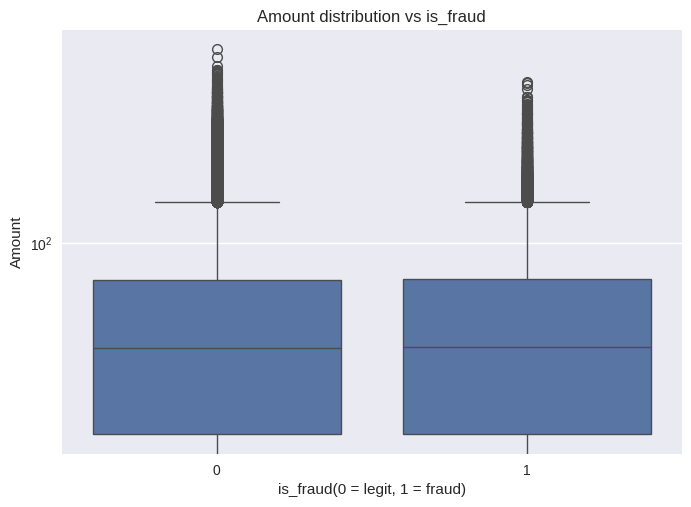

In [49]:
fig, ax = plt.subplots()

sns.boxplot(x='is_fraud', y='amount', data=df, ax=ax)
ax.set_title('Amount distribution vs is_fraud')
ax.set_xlabel('is_fraud(0 = legit, 1 = fraud)')
ax.set_ylabel('Amount')
ax.set_yscale('log')

#### Summary:
- amount is not a discriminative feature by itself for froud detection
- distribution are very similar
- may still be useful when combined with other features

Text(0, 0.5, 'Session length seconds')

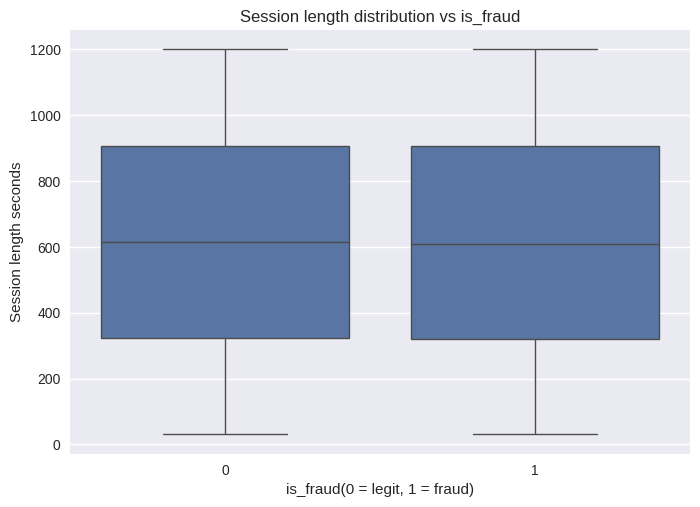

In [50]:
fig, ax = plt.subplots()

sns.boxplot(x='is_fraud', y='session_length_seconds', data=df, ax=ax)
ax.set_title('Session length distribution vs is_fraud')
ax.set_xlabel('is_fraud(0 = legit, 1 = fraud)')
ax.set_ylabel('Session length seconds')
# ax.set_yscale('log')